## Importacion de Libreria

In [24]:
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import pandas as pd
from dotenv import load_dotenv
import os
from pathlib import Path

In [25]:
#Obtencion de servidor Sql

load_dotenv()  # ← carga el .env

DB_SERVER = os.getenv("DB_SERVER")
DB_NAME = os.getenv("DB_NAME")

In [43]:
# Conectar la info del API al SQL y guardar los datos en la base de datos para su posterior análisis.
engine = create_engine(
    f"mssql+pyodbc://{DB_SERVER}/{DB_NAME}"
    f"?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

## Informacion de los partidos de la Liga

In [4]:
carpeta = r'C:\Users\brger\OneDrive\Desktop\Project\Football_Prediction\Data\raw'
temporadas = list(Path(carpeta).glob('*.csv'))
temporadas

[WindowsPath('C:/Users/brger/OneDrive/Desktop/Project/Football_Prediction/Data/raw/SP1_0001.csv'),
 WindowsPath('C:/Users/brger/OneDrive/Desktop/Project/Football_Prediction/Data/raw/SP1_0102.csv'),
 WindowsPath('C:/Users/brger/OneDrive/Desktop/Project/Football_Prediction/Data/raw/SP1_0203.csv'),
 WindowsPath('C:/Users/brger/OneDrive/Desktop/Project/Football_Prediction/Data/raw/SP1_0304.csv'),
 WindowsPath('C:/Users/brger/OneDrive/Desktop/Project/Football_Prediction/Data/raw/SP1_0405.csv'),
 WindowsPath('C:/Users/brger/OneDrive/Desktop/Project/Football_Prediction/Data/raw/SP1_0506.csv'),
 WindowsPath('C:/Users/brger/OneDrive/Desktop/Project/Football_Prediction/Data/raw/SP1_0607.csv'),
 WindowsPath('C:/Users/brger/OneDrive/Desktop/Project/Football_Prediction/Data/raw/SP1_0708.csv'),
 WindowsPath('C:/Users/brger/OneDrive/Desktop/Project/Football_Prediction/Data/raw/SP1_0809.csv'),
 WindowsPath('C:/Users/brger/OneDrive/Desktop/Project/Football_Prediction/Data/raw/SP1_0910.csv'),
 WindowsPa

In [5]:
df1 = pd.DataFrame()

for temporada in temporadas:
    Campaña = temporada.stem.split('_')[1]
    print(f"Procesando temporada: {Campaña}")
    
    try:
        df = pd.read_csv(temporada, sep=',', on_bad_lines='skip', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(temporada, sep=',', on_bad_lines='skip', encoding='latin-1')
    
    df['temporada'] = Campaña          # primero asigna la columna
    df.drop(columns=['Div'], inplace=True, errors='ignore')  # luego elimina Div
    df1 = pd.concat([df1, df], ignore_index=True)  # finalmente concatena

print(f"✅ Total filas: {len(df1)}")

Procesando temporada: 0001
Procesando temporada: 0102
Procesando temporada: 0203
Procesando temporada: 0304
Procesando temporada: 0405
Procesando temporada: 0506
Procesando temporada: 0607
Procesando temporada: 0708
Procesando temporada: 0809
Procesando temporada: 0910
Procesando temporada: 1011
Procesando temporada: 1112
Procesando temporada: 1213
Procesando temporada: 1314
Procesando temporada: 1415
Procesando temporada: 1516
Procesando temporada: 1617
Procesando temporada: 1718
Procesando temporada: 1819
Procesando temporada: 1920
Procesando temporada: 2021
Procesando temporada: 2122
Procesando temporada: 2223
Procesando temporada: 2324
Procesando temporada: 2425
Procesando temporada: 2526
✅ Total filas: 9658


In [6]:
df1.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9658 entries, 0 to 9657
Data columns (total 213 columns):
 #    Column       Non-Null Count  Dtype  
---   ------       --------------  -----  
 0    Date         9658 non-null   object 
 1    HomeTeam     9658 non-null   object 
 2    AwayTeam     9658 non-null   object 
 3    FTHG         9658 non-null   int64  
 4    FTAG         9658 non-null   int64  
 5    FTR          9658 non-null   object 
 6    HTHG         9658 non-null   int64  
 7    HTAG         9658 non-null   int64  
 8    HTR          9658 non-null   object 
 9    GBH          4729 non-null   float64
 10   GBD          4729 non-null   float64
 11   GBA          4729 non-null   float64
 12   IWH          8796 non-null   float64
 13   IWD          8796 non-null   float64
 14   IWA          8796 non-null   float64
 15   LBH          6876 non-null   float64
 16   LBD          6876 non-null   float64
 17   LBA          6876 non-null   float64
 18   SBH          4395 non-null

In [7]:
df1

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,GBH,...,BMGMCA,BVCH,BVCD,BVCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,09/09/00,Barcelona,Malaga,2,1,H,2,0,H,1.28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,09/09/00,La Coruna,Ath Bilbao,2,0,H,0,0,D,1.51,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,09/09/00,Real Madrid,Valencia,2,1,H,0,0,D,1.65,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,09/09/00,Sociedad,Santander,2,2,D,0,0,D,1.85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,09/09/00,Zaragoza,Espanol,1,2,A,0,0,D,1.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9653,08/03/2026,Villarreal,Elche,2,1,H,2,0,H,NaN,...,6.75,1.44,4.75,7.00,NaN,NaN,NaN,NaN,NaN,NaN
9654,08/03/2026,Getafe,Betis,2,0,H,2,0,H,NaN,...,2.95,2.70,2.80,3.10,NaN,NaN,NaN,NaN,NaN,NaN
9655,08/03/2026,Sevilla,Vallecano,1,1,D,1,0,H,NaN,...,2.95,2.50,3.13,3.00,NaN,NaN,NaN,NaN,NaN,NaN
9656,08/03/2026,Valencia,Alaves,3,2,H,0,1,A,NaN,...,3.95,2.05,3.10,4.10,NaN,NaN,NaN,NaN,NaN,NaN


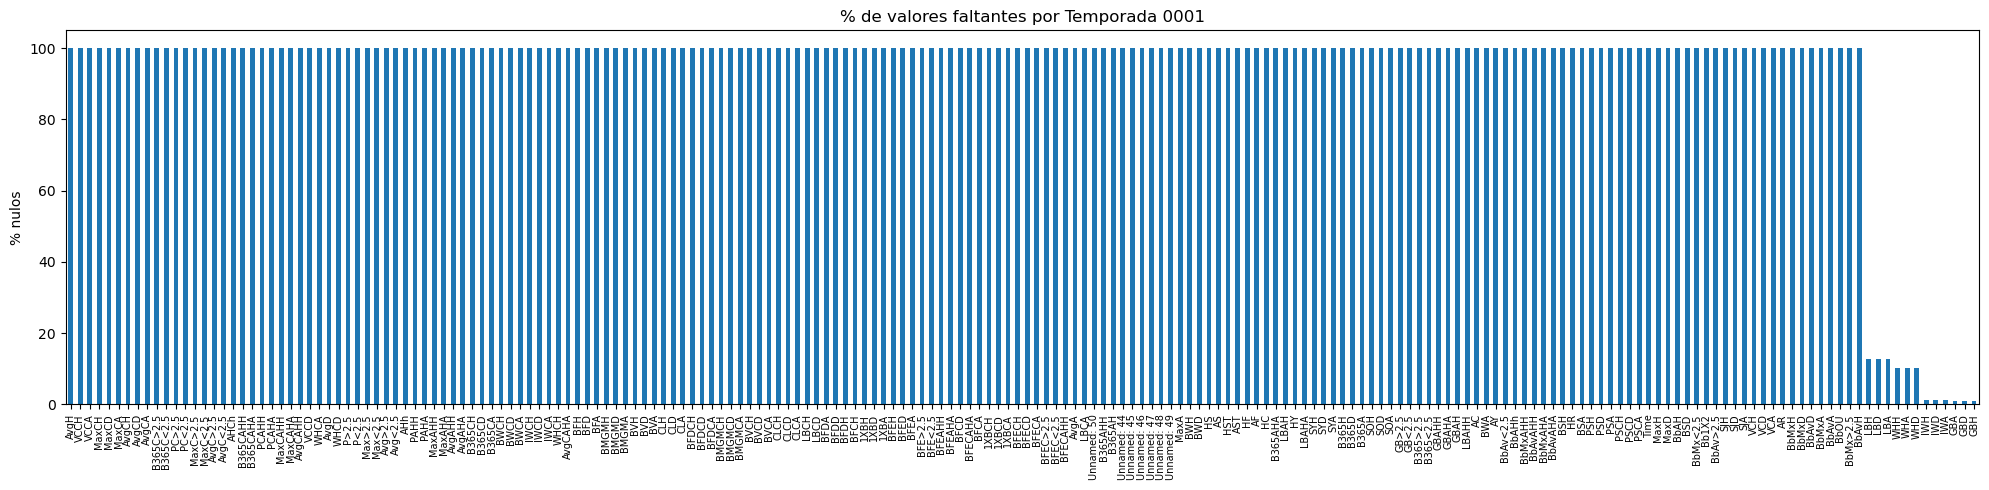

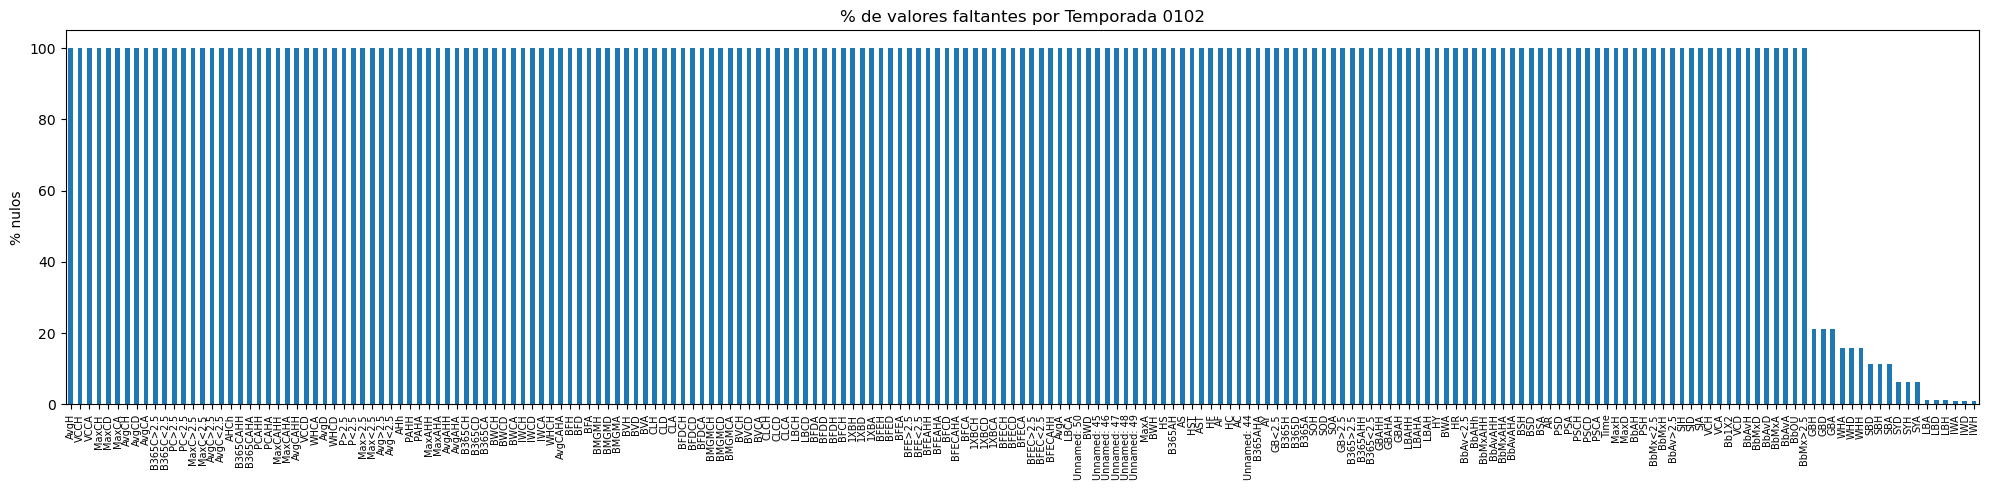

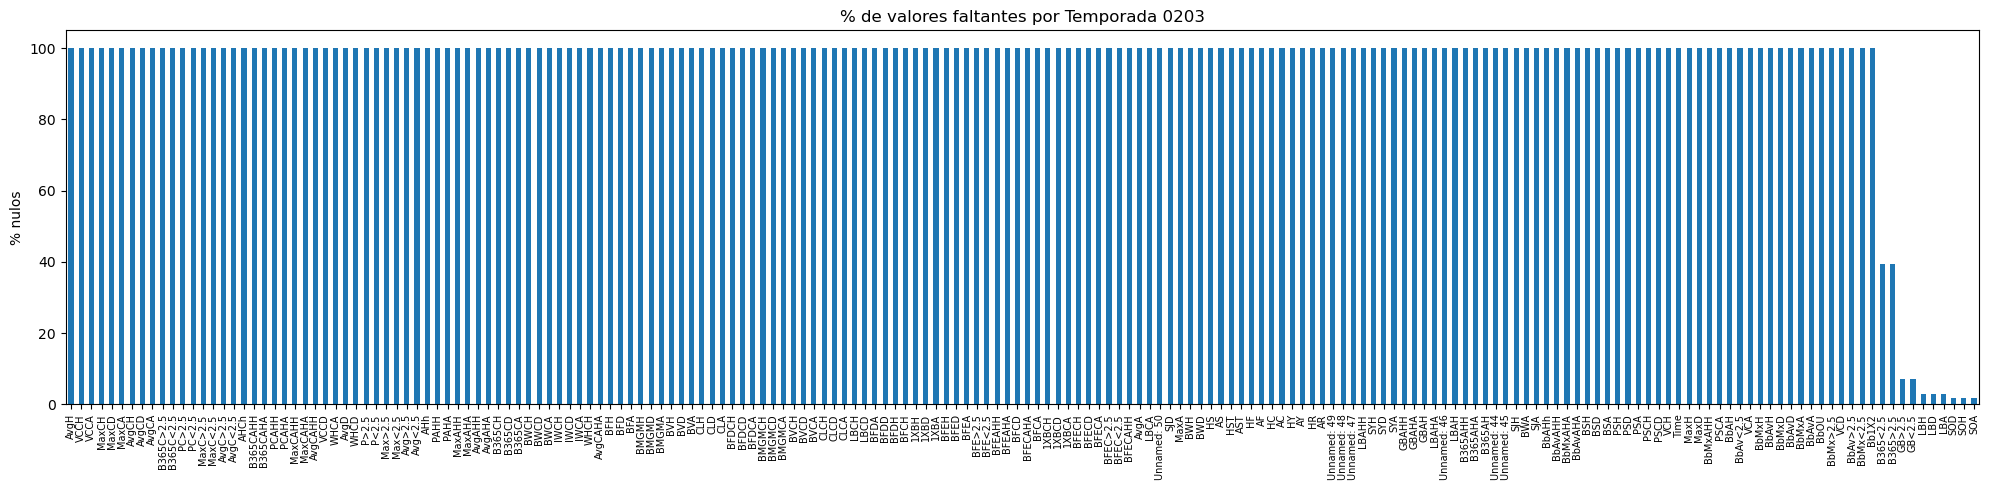

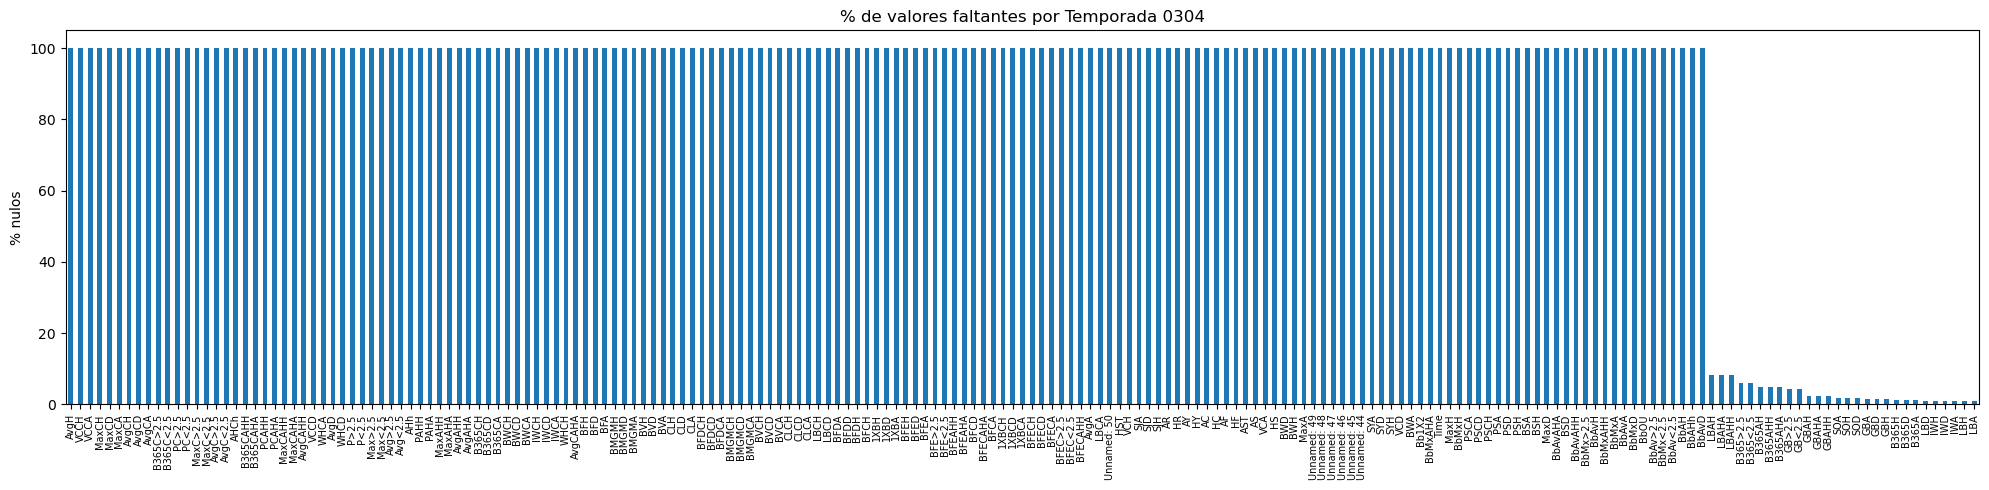

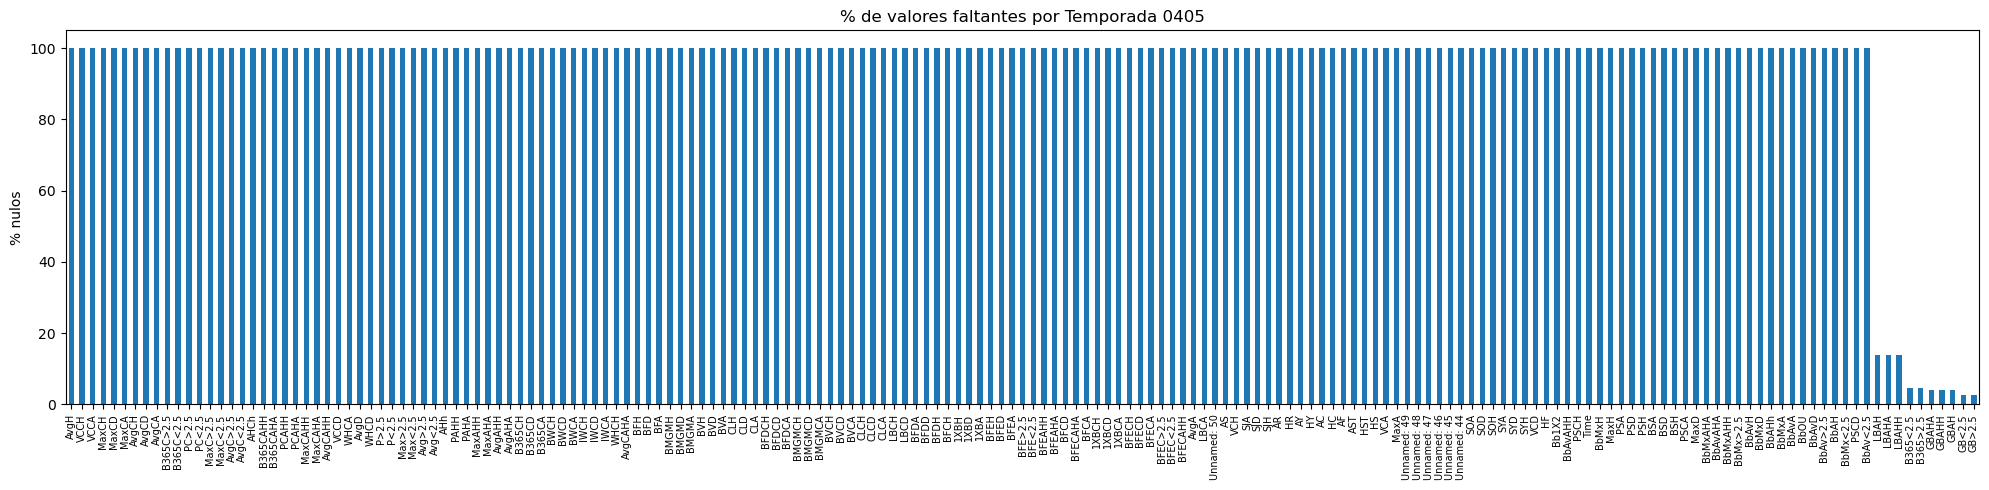

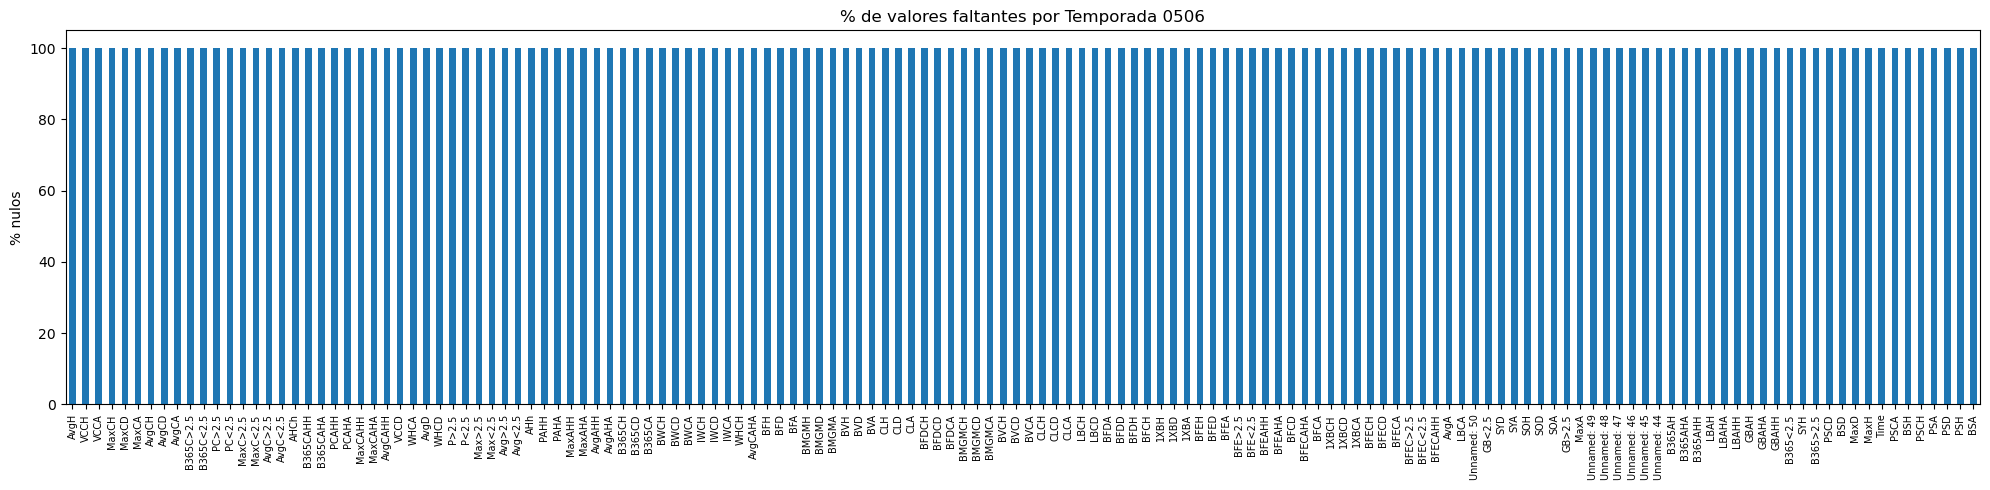

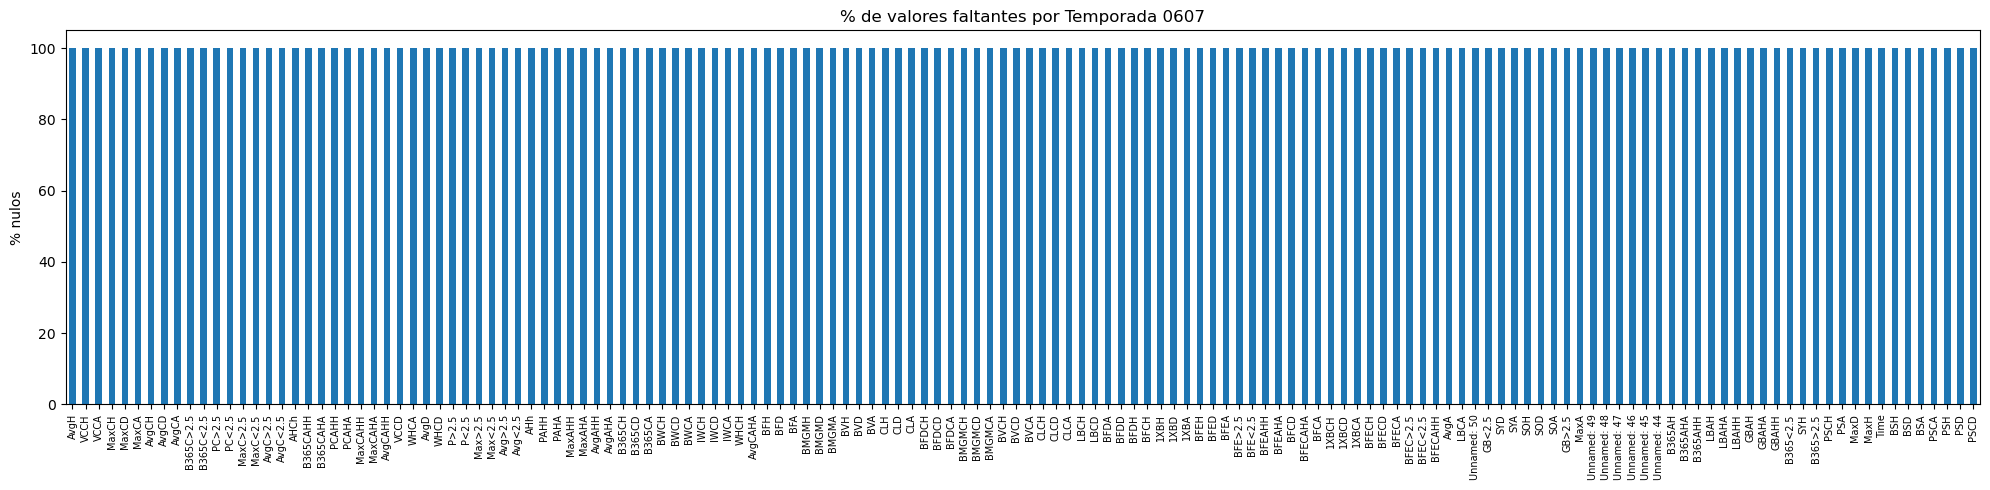

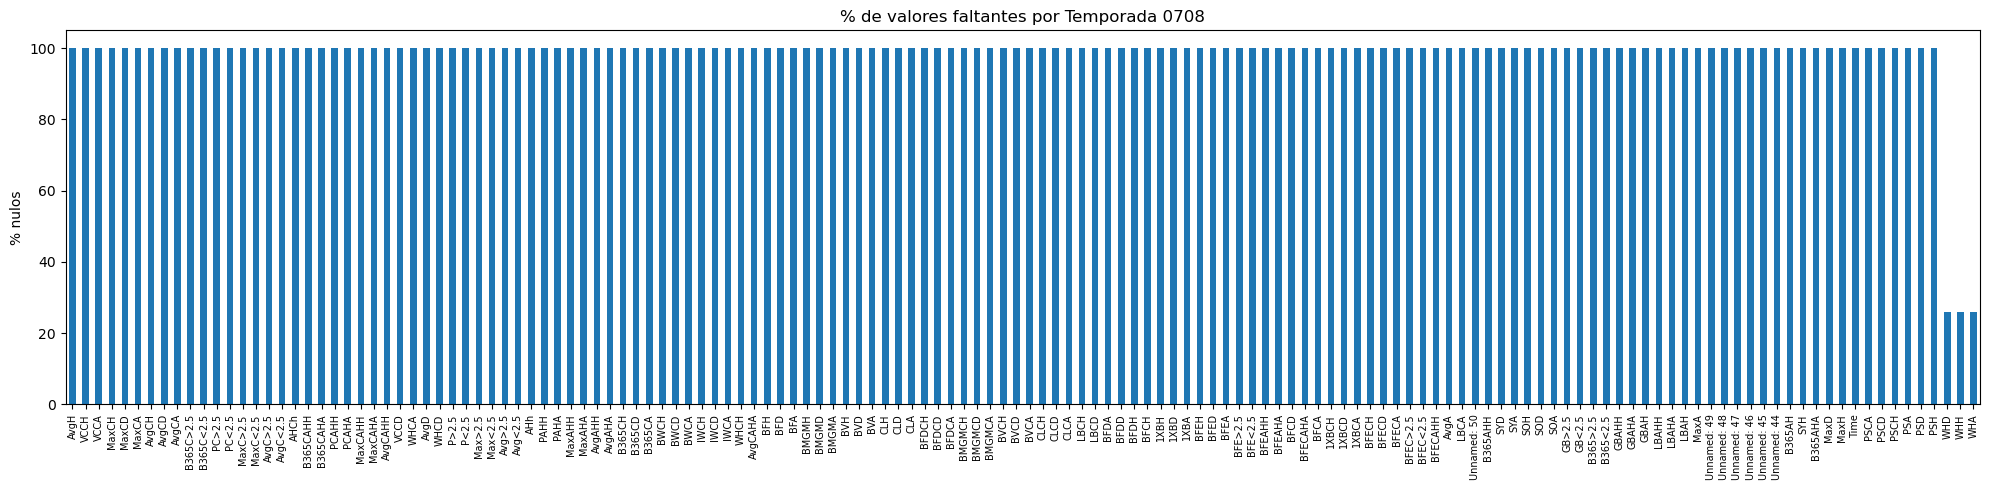

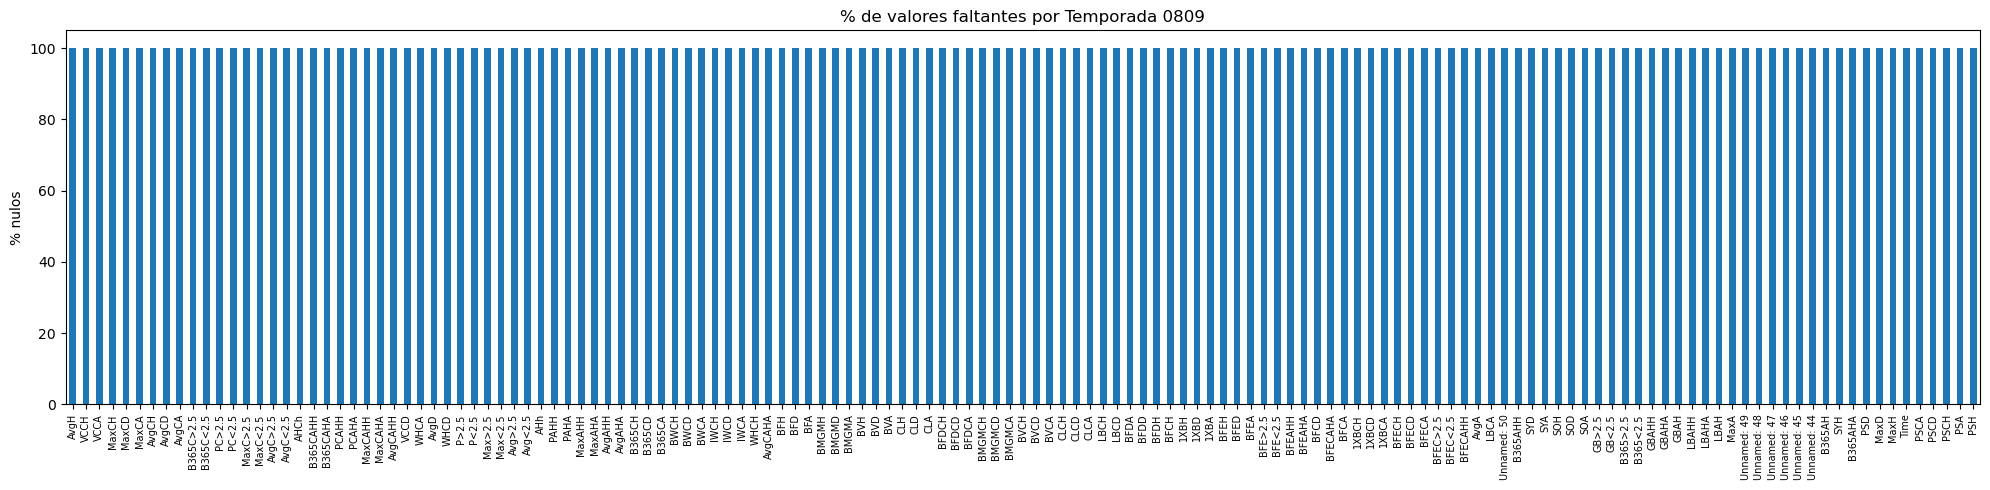

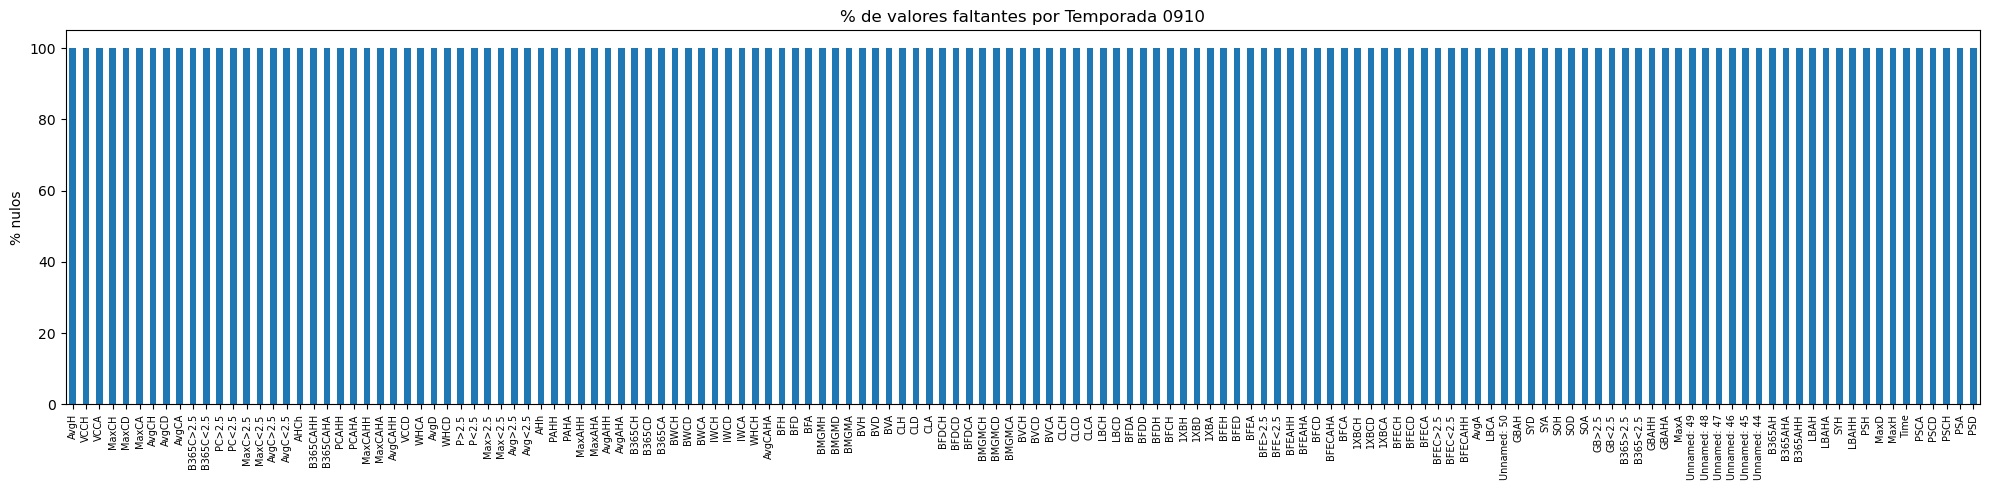

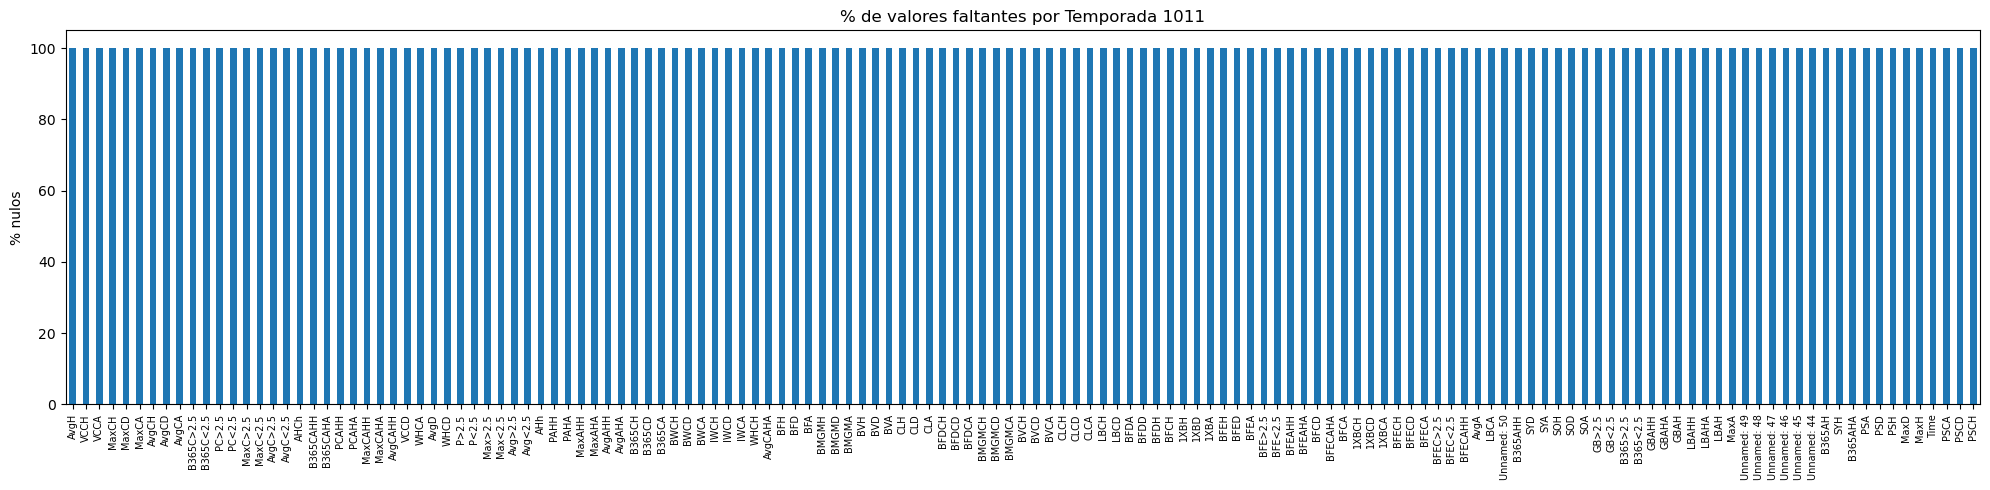

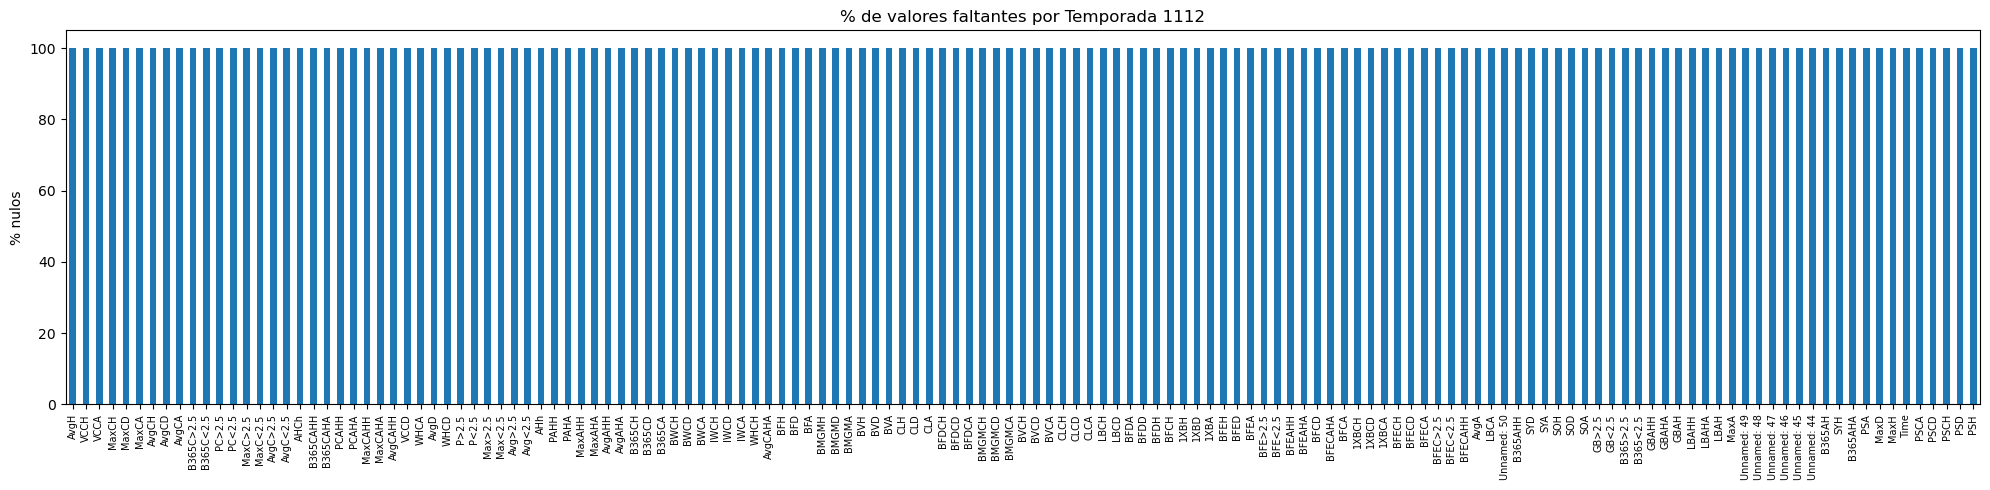

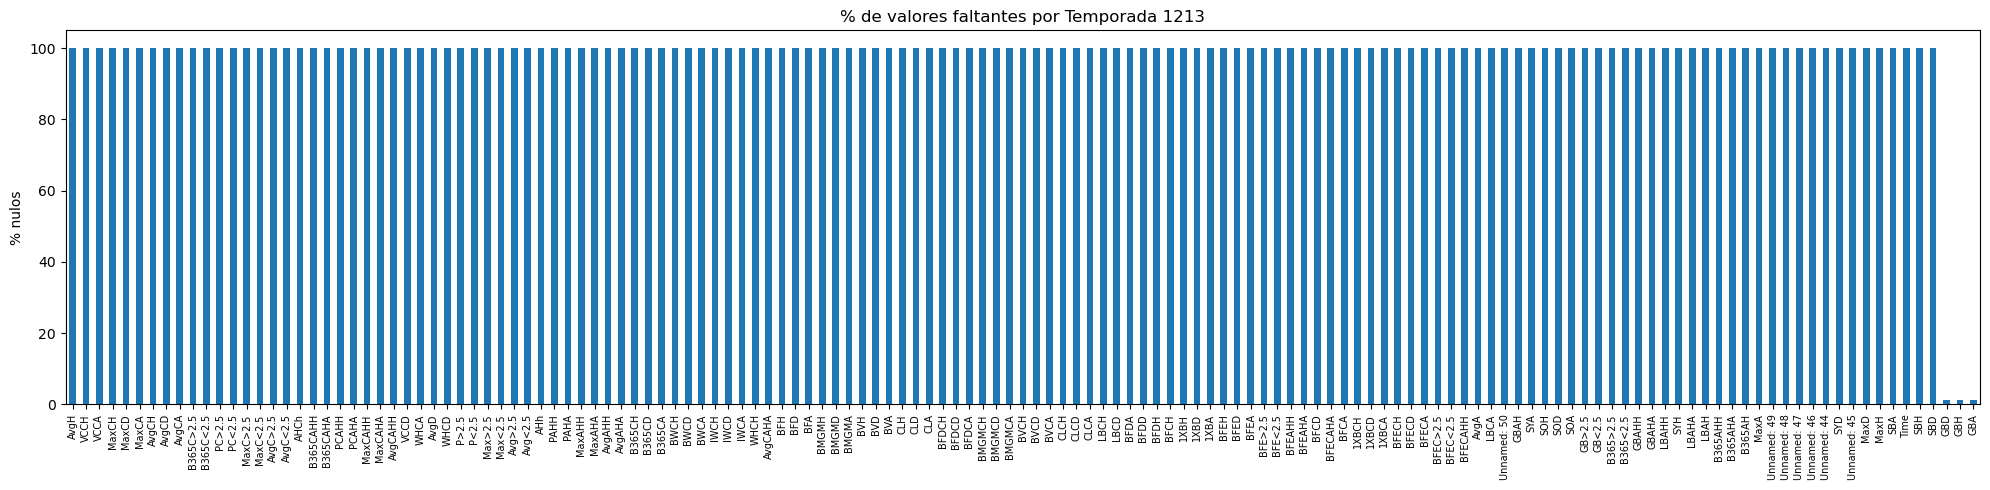

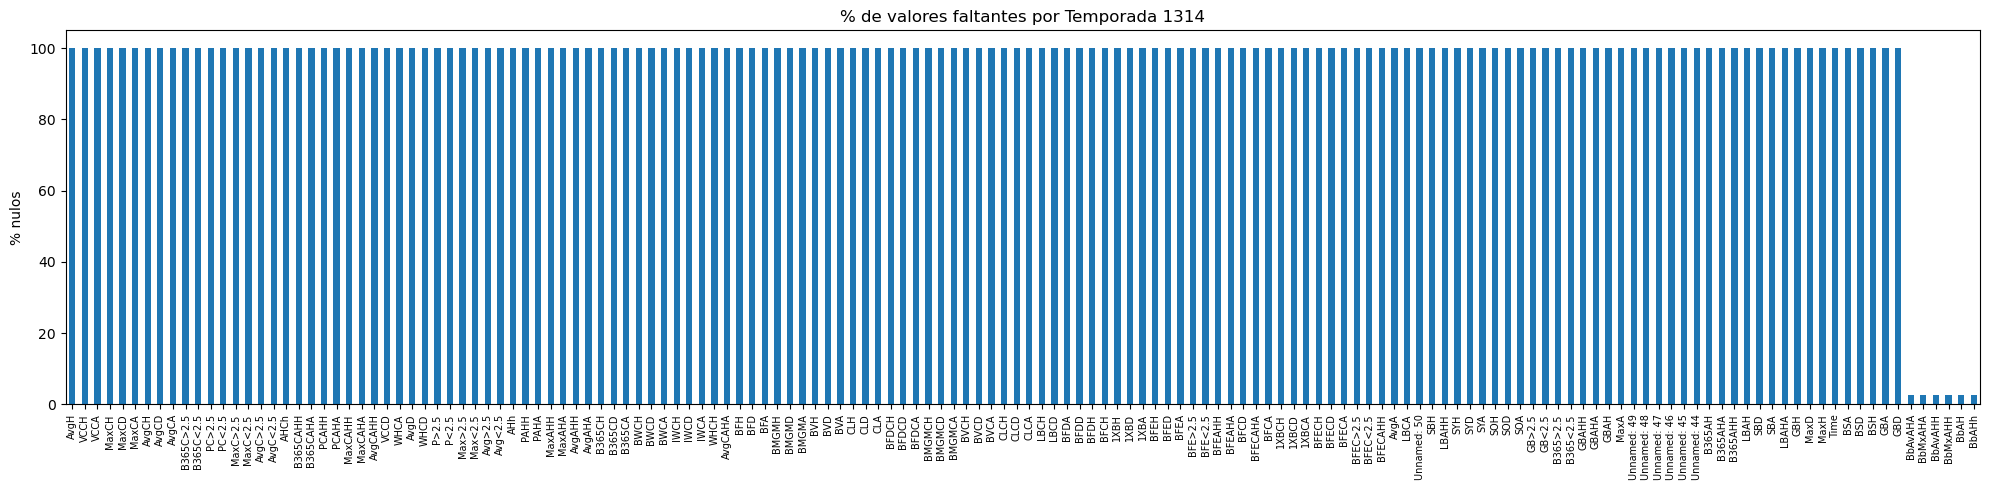

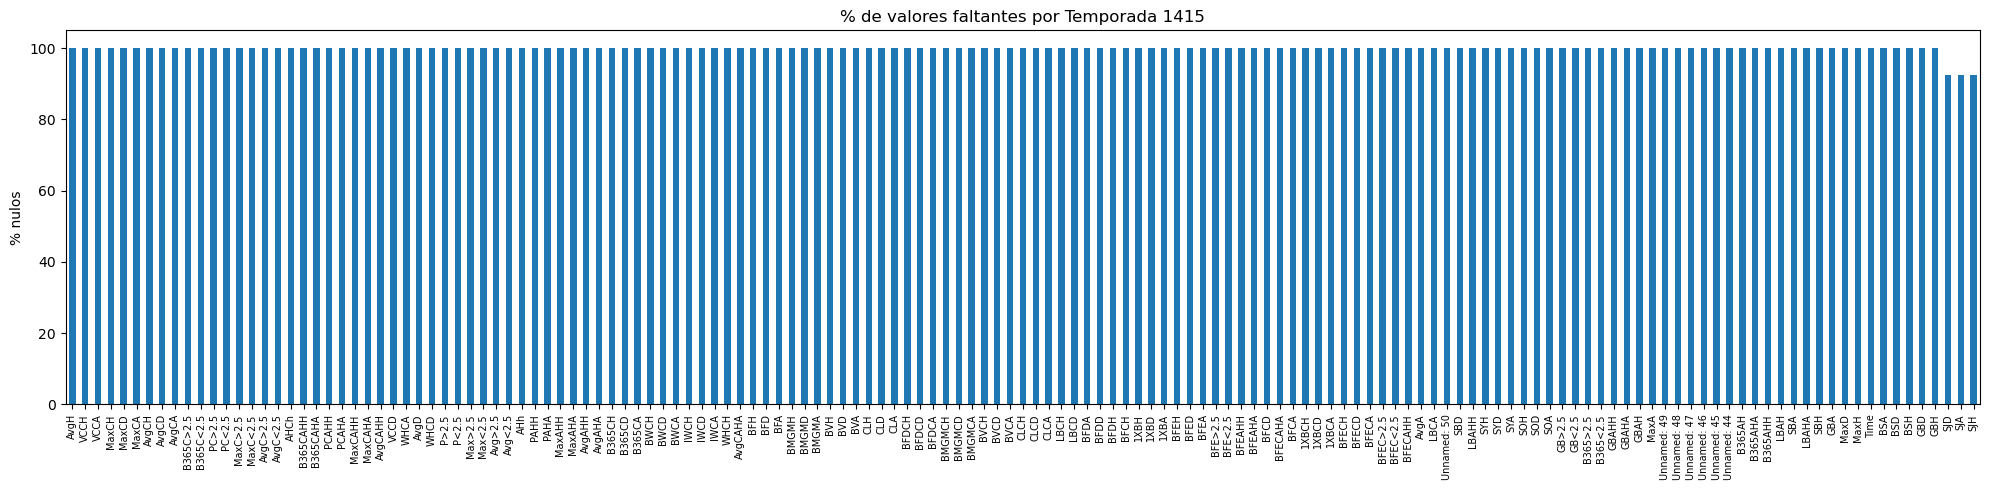

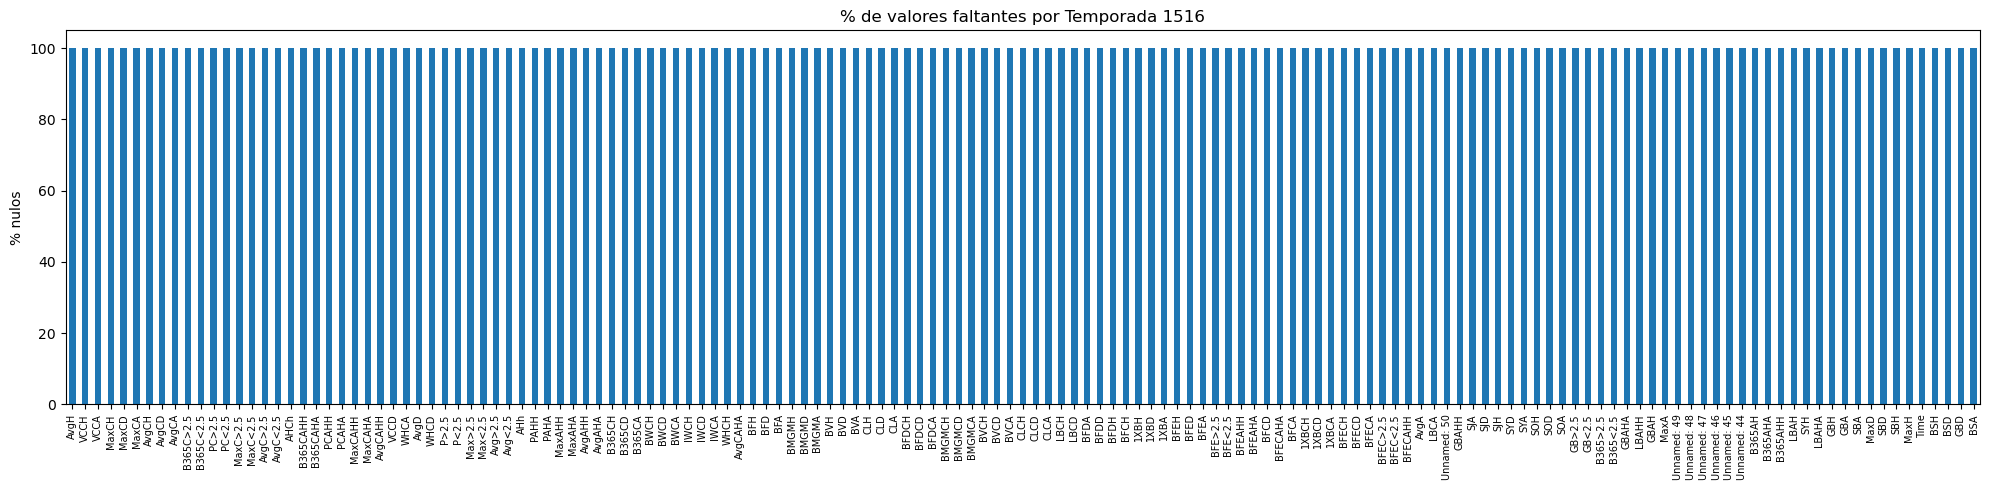

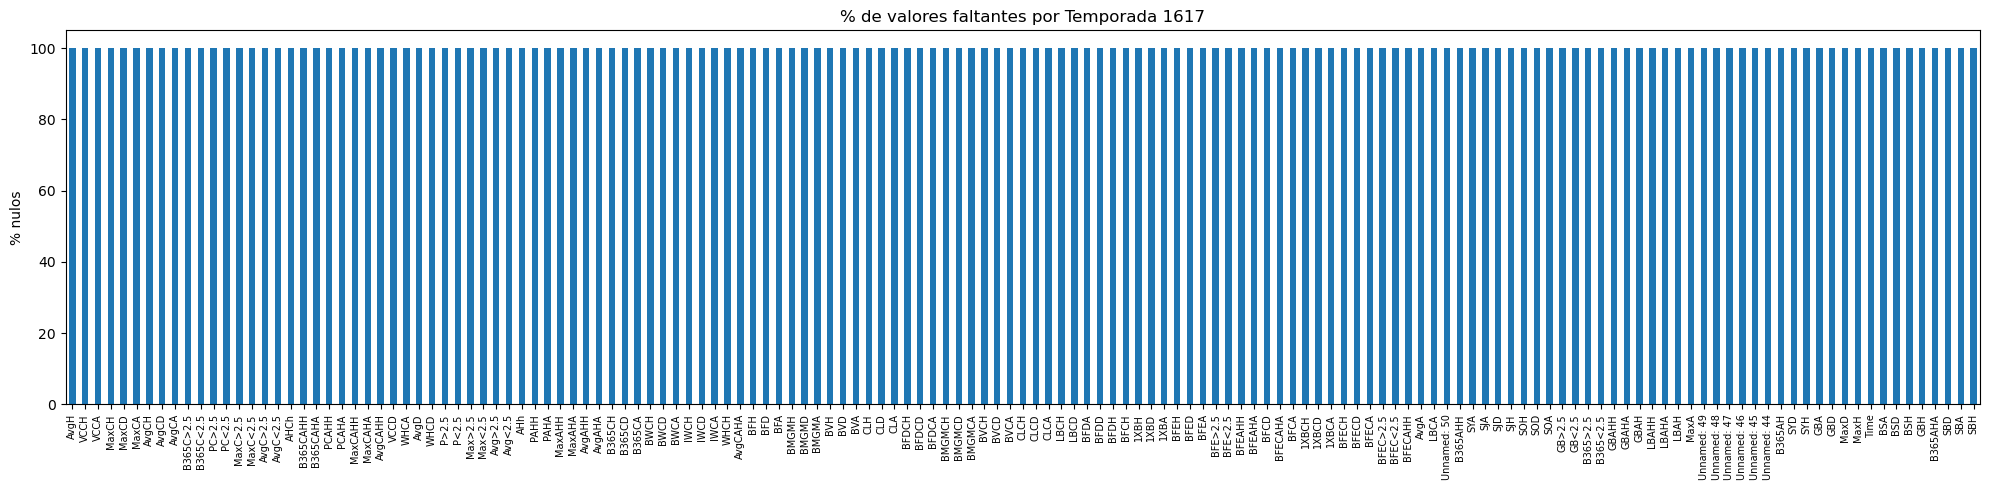

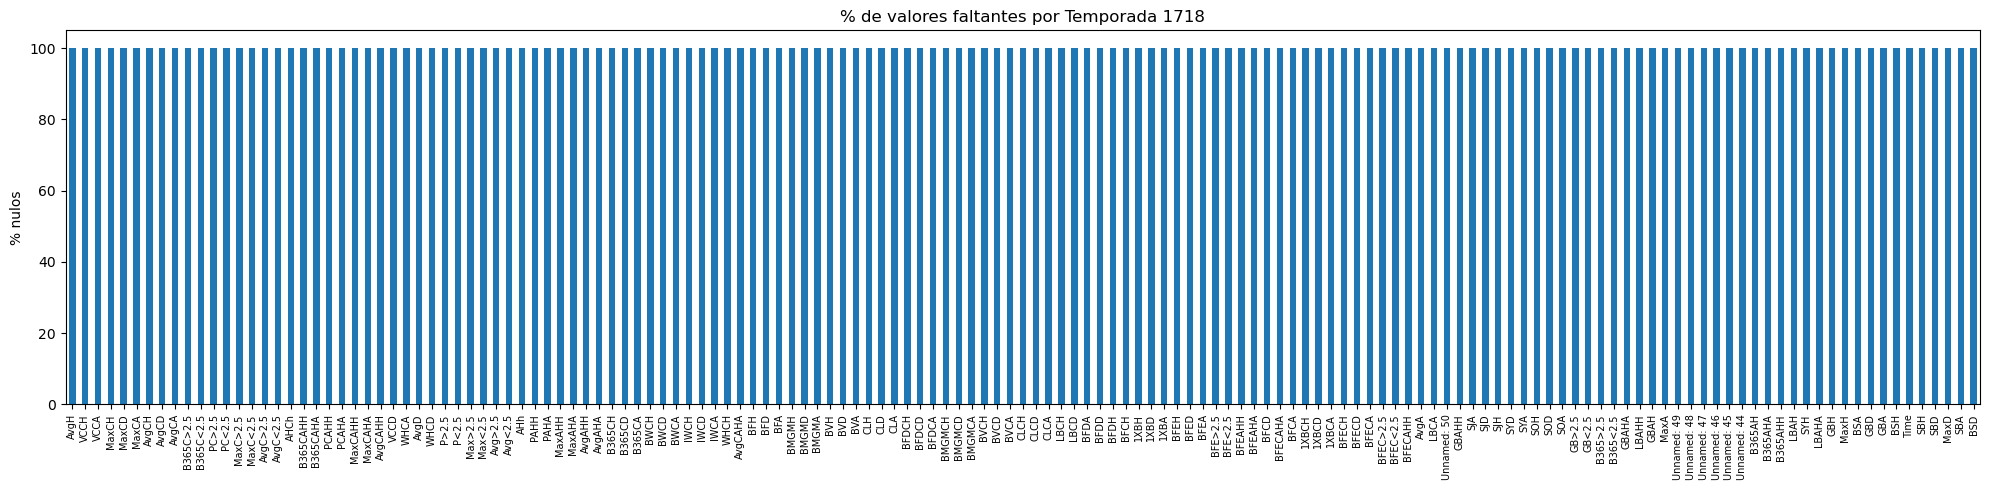

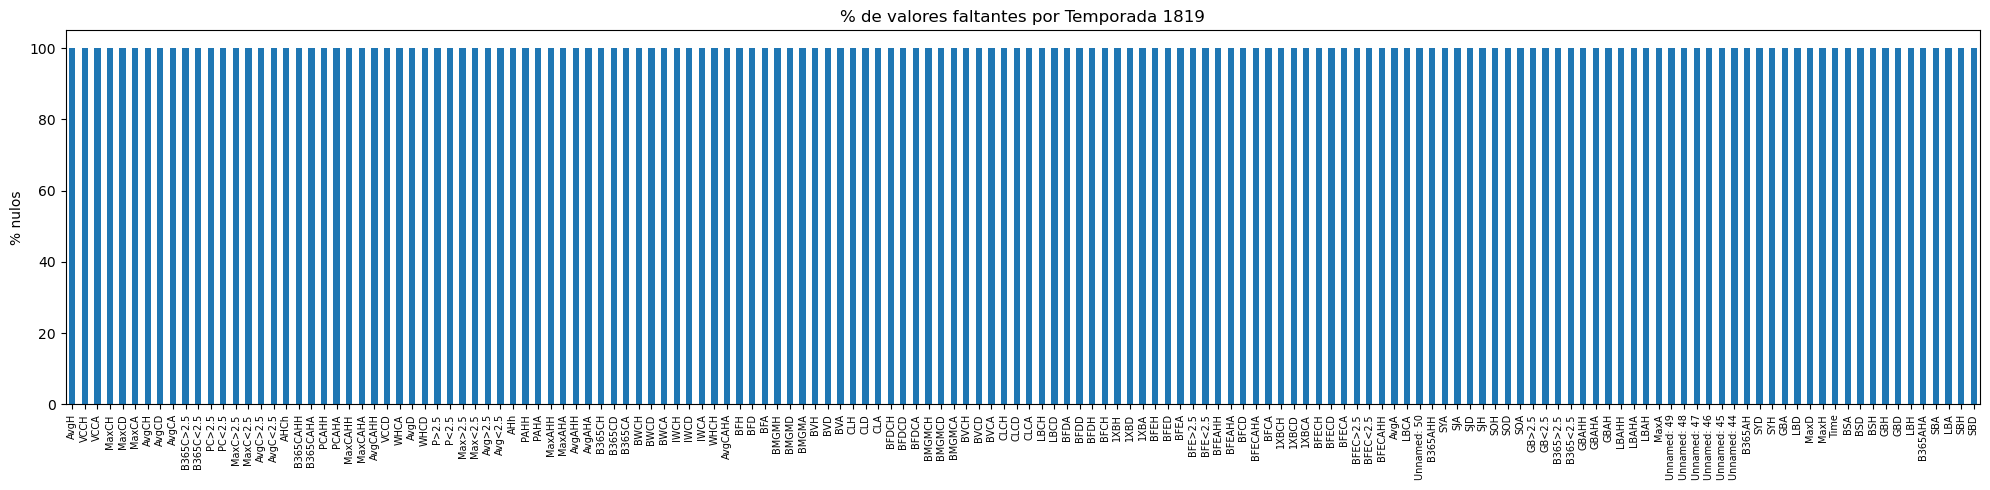

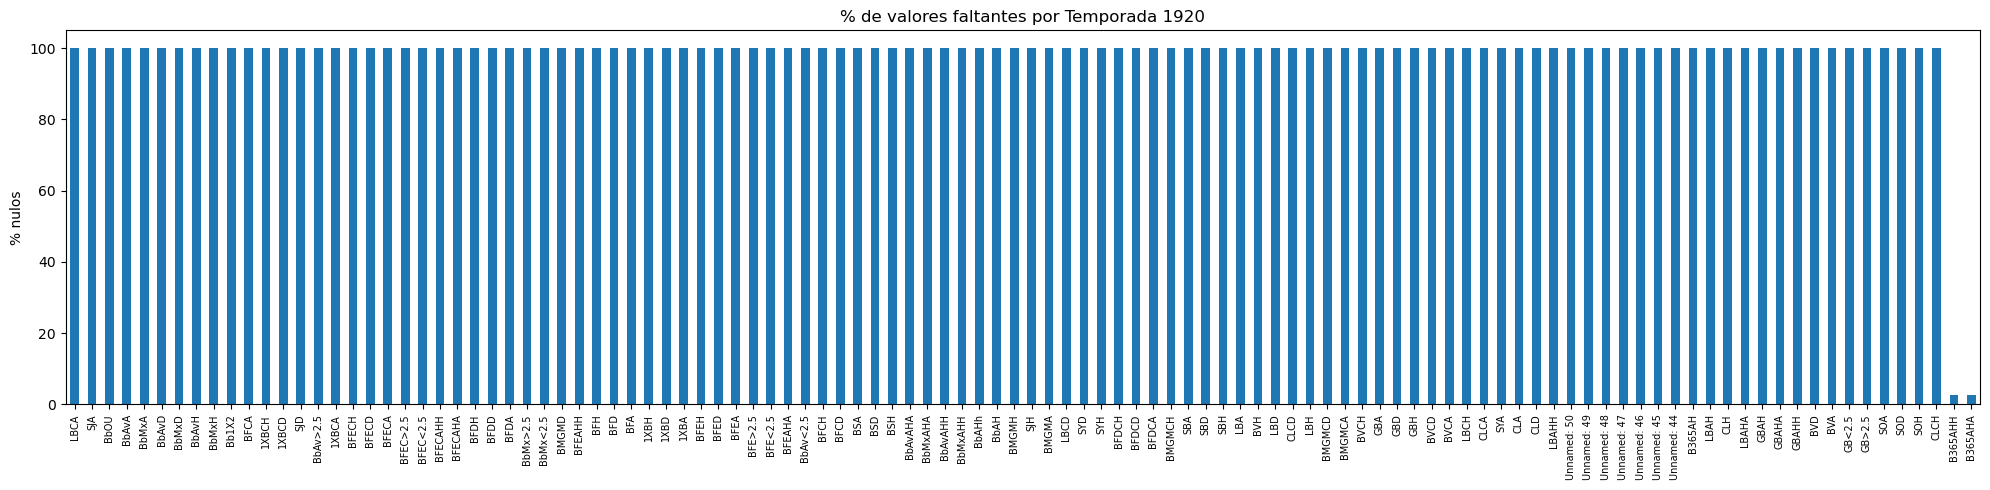

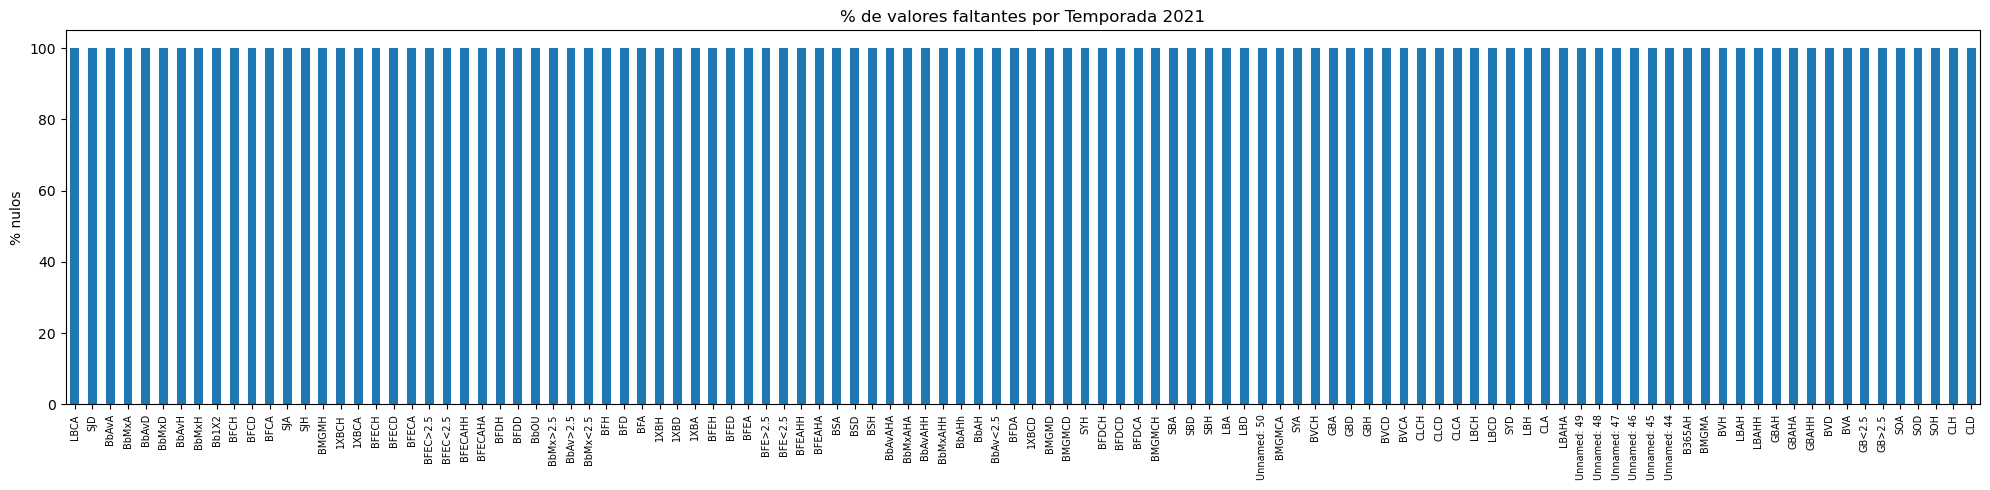

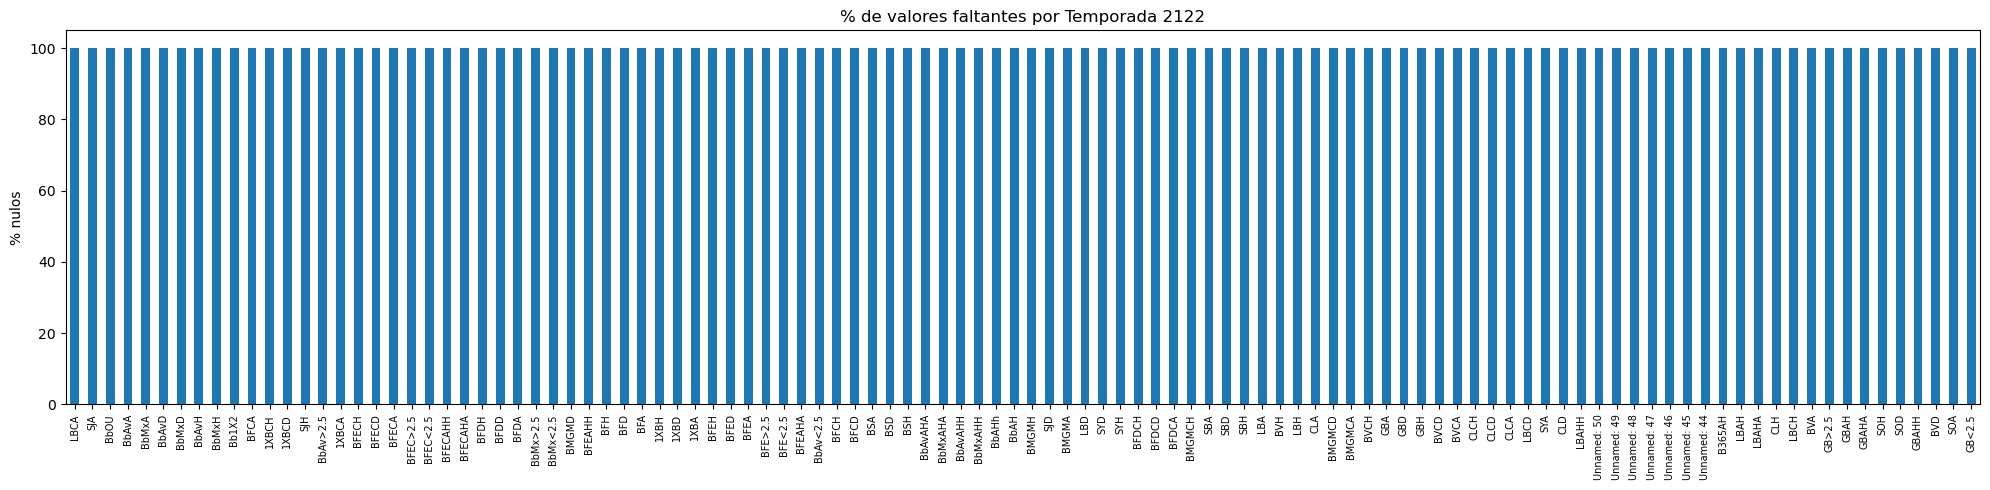

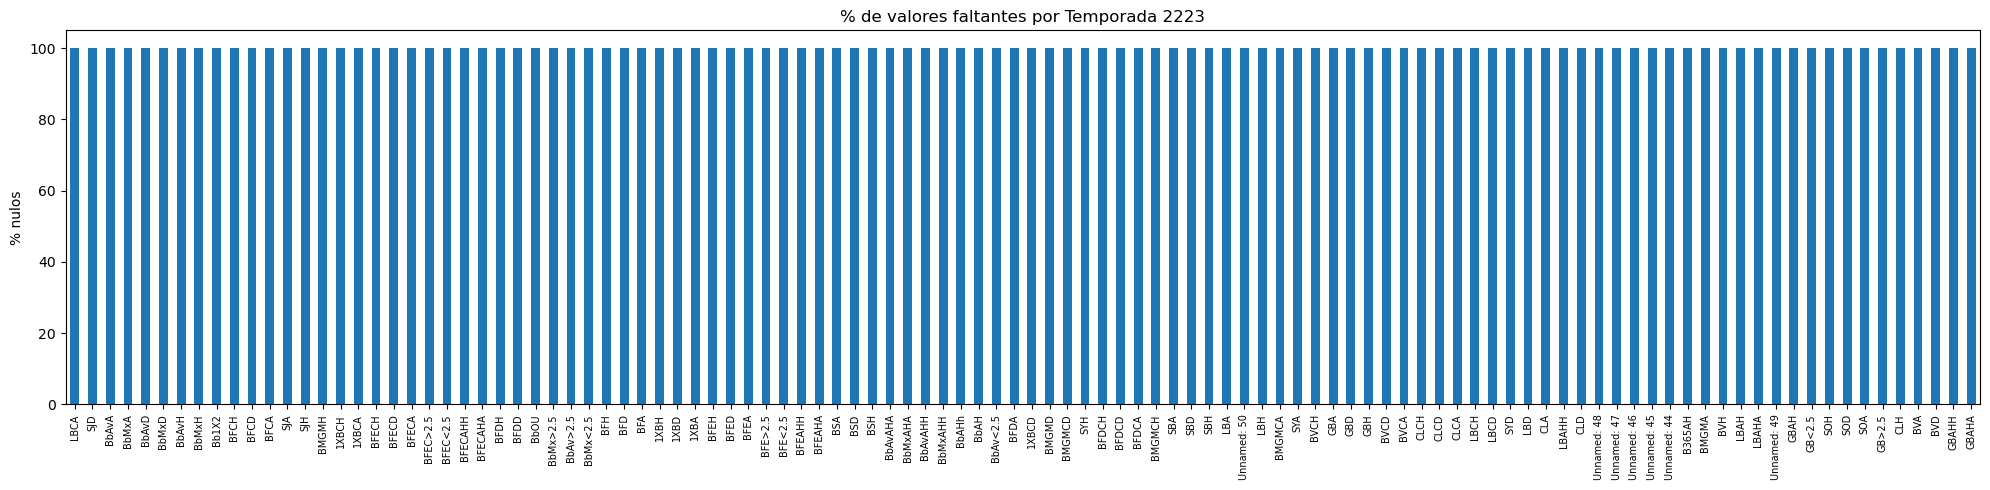

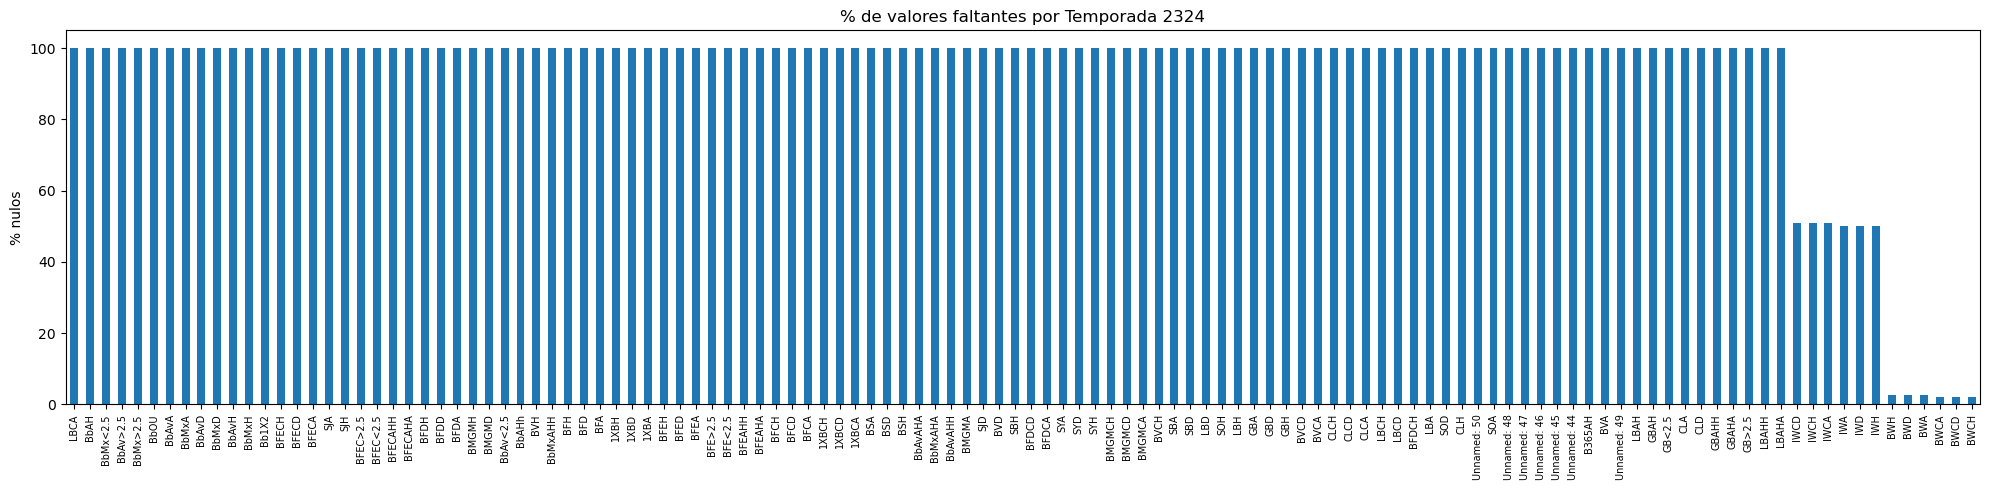

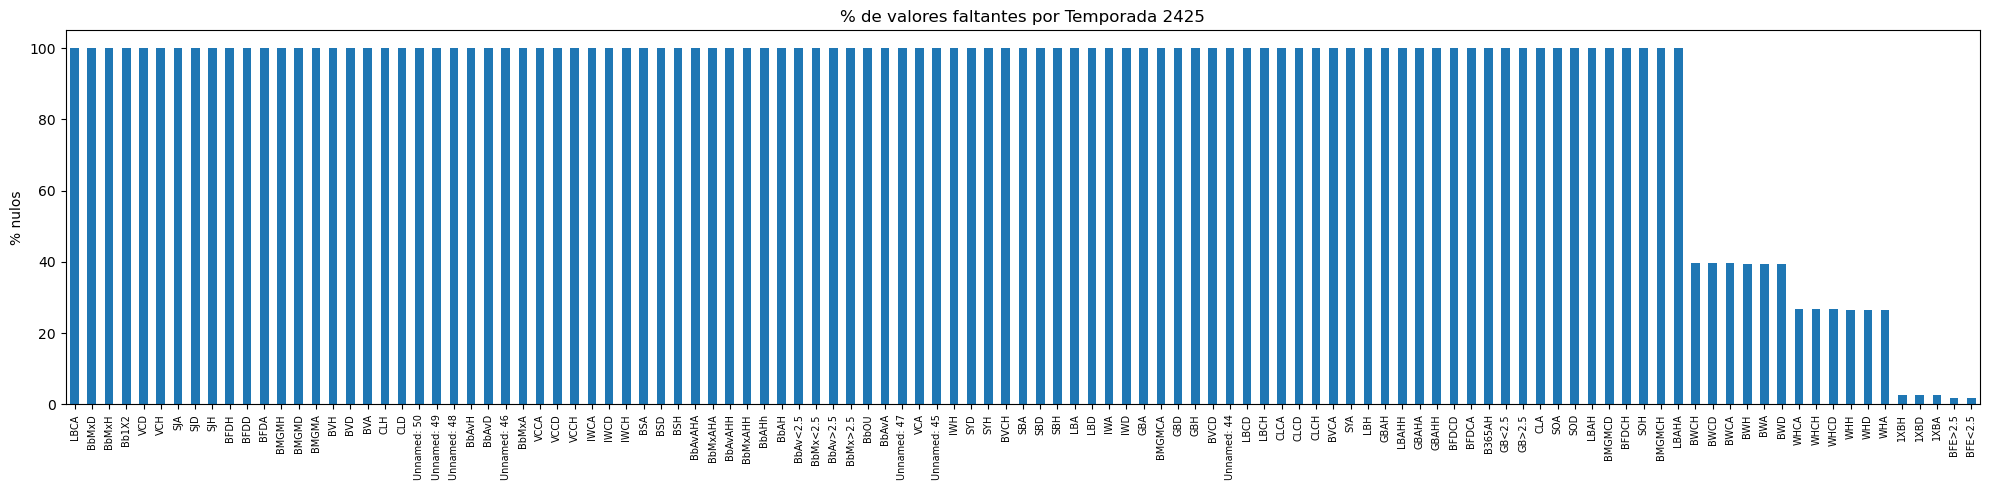

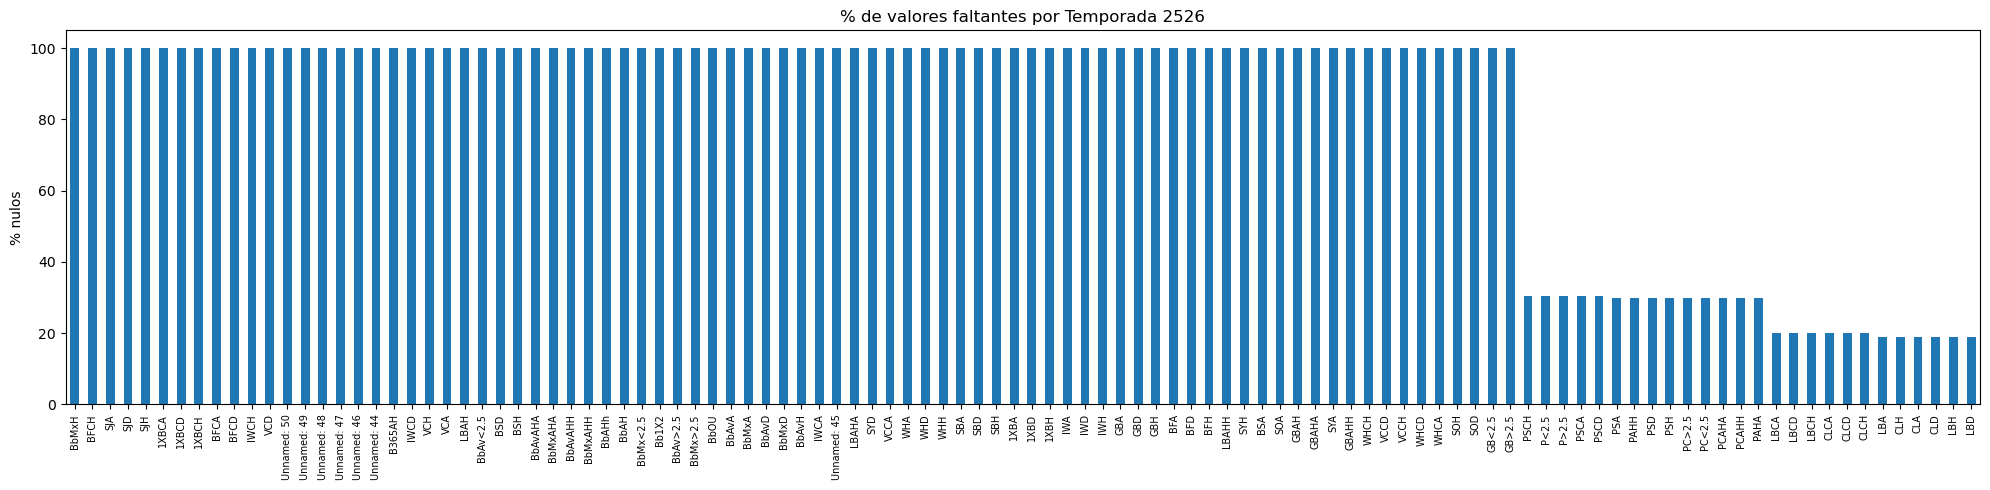

In [8]:
for season in df1.temporada.unique():
    df_season = df1[df1['temporada'] == season]
    
    nulos = (df_season.isnull().sum() / len(df_season) * 100).sort_values(ascending=False)
    nulos = nulos[nulos > 1]

    plt.figure(figsize=(20, 5))
    nulos.plot(kind='bar')
    plt.title(f"% de valores faltantes por Temporada {season}")
    plt.ylabel("% nulos")
    plt.xticks(rotation=90, fontsize=7)
    plt.tight_layout()
    plt.show()

In [9]:
# Eliminar columnas Unnamed
unnamed = [col for col in df1.columns if 'Unnamed' in col]
print(f"Columnas a eliminar: {unnamed}")
df1.drop(columns=unnamed, inplace=True)
print(f"✅ Columnas restantes: {df1.shape[1]}")


Columnas a eliminar: ['Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50']
✅ Columnas restantes: 206


In [10]:
# Ver % de nulos solo de columnas importantes
columnas_clave = ['Date','HomeTeam','AwayTeam','FTHG','FTAG','FTR',
                  'HTHG','HTAG','HTR','HS','AS','HST','AST',
                  'HC','AC','HY','AY','HR','AR','temporada']

nulos = df1[columnas_clave].isnull().sum()
nulos_pct = (nulos / len(df1) * 100).round(1)
pd.DataFrame({'nulos': nulos, '%': nulos_pct})

,nulos,%
Date,0,0.0
HomeTeam,0,0.0
AwayTeam,0,0.0
FTHG,0,0.0
FTAG,0,0.0
FTR,0,0.0
HTHG,0,0.0
HTAG,0,0.0
HTR,0,0.0
HS,1788,18.5


Los nulos corresponden de las temporadas 2000/2001 hasta el 2004/2005 porque no se registraban esos indicadores en su momento

In [11]:
# Corregir Date
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True, errors='coerce')

df1['Time'] = pd.to_datetime(df1['Time'], format='%H:%M', errors='coerce').dt.time

C:\Users\brger\AppData\Local\Temp\ipykernel_13340\436160361.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True, errors='coerce')


In [12]:
df1['Date'].dtype  # debe decir datetime64[ns]

dtype('<M8[ns]')

In [ ]:
# Columnas Asian Handicap a eliminar
asian_handicap = [col for col in fact_partido.columns if 'AH' in col or 'AHh' in col.lower()]
print(f"Columnas AH a eliminar: {asian_handicap}")

fact_partido.drop(columns=asian_handicap, inplace=True)
print(f"✅ Columnas restantes: {fact_partido.shape[1]}")

## Armar DIM_EQUIPO

In [13]:
# combinar los equipos de ambas columnas y sacar los únicos
equipos = pd.concat([df1['HomeTeam'], df1['AwayTeam']]).unique()

In [14]:
equipos

array(['Barcelona', 'La Coruna', 'Real Madrid', 'Sociedad', 'Zaragoza',
       'Las Palmas', 'Mallorca', 'Numancia', 'Osasuna', 'Villarreal',
       'Ath Bilbao', 'Malaga', 'Santander', 'Valencia', 'Valladolid',
       'Alaves', 'Celta', 'Espanol', 'Oviedo', 'Vallecano', 'Sevilla',
       'Tenerife', 'Betis', 'Recreativo', 'Ath Madrid', 'Albacete',
       'Murcia', 'Getafe', 'Levante', 'Cadiz', 'Gimnastic', 'Almeria',
       'Sp Gijon', 'Xerez', 'Hercules', 'Granada', 'Elche', 'Eibar',
       'Cordoba', 'Leganes', 'Girona', 'Huesca'], dtype=object)

In [15]:
dim_equipo = pd.DataFrame({
    'nombre': sorted(equipos)
})

## Armar la bd de DIM_FECHAS

In [16]:
dim_fecha = pd.DataFrame({
    'fecha'     : df1['Date'].unique()
})

In [17]:
pd.merge(dim_fecha,df1,left_on='fecha',right_on='Date',how='right')[['temporada']]

,temporada
0,0001
1,0001
2,0001
3,0001
4,0001
...,...
9653,2526
9654,2526
9655,2526
9656,2526


In [18]:
dim_fecha['Año'] = dim_fecha['fecha'].dt.year
dim_fecha['Mes'] = dim_fecha['fecha'].dt.month
dim_fecha['Nombre_Mes']  = dim_fecha['fecha'].dt.month_name(locale = 'es')
dim_fecha['Semana']     = dim_fecha['fecha'].dt.isocalendar().week.astype(int)
dim_fecha['Dia'] = dim_fecha['fecha'].dt.day
dim_fecha['Nombre_Dia'] = dim_fecha['fecha'].dt.day_name(locale='es')
fecha_temporada = df1[['Date','temporada']].drop_duplicates()
dim_fecha = dim_fecha.merge(fecha_temporada, left_on='fecha', right_on='Date', how='left').drop(columns='Date')


In [19]:
dim_fecha

,fecha,Año,Mes,Nombre_Mes,Semana,Dia,Nombre_Dia,temporada
0,2000-09-09,2000,9,Septiembre,36,9,Sábado,0001
1,2000-09-10,2000,9,Septiembre,36,10,Domingo,0001
2,2000-09-16,2000,9,Septiembre,37,16,Sábado,0001
3,2000-09-17,2000,9,Septiembre,37,17,Domingo,0001
4,2000-09-23,2000,9,Septiembre,38,23,Sábado,0001
...,...,...,...,...,...,...,...,...
2809,2026-03-04,2026,3,Marzo,10,4,Miércoles,2526
2810,2026-03-06,2026,3,Marzo,10,6,Viernes,2526
2811,2026-03-07,2026,3,Marzo,10,7,Sábado,2526
2812,2026-03-08,2026,3,Marzo,10,8,Domingo,2526


## Conectar Las DIM  en la bd de PARTIDOS

In [28]:
#DIM_EQUIPO
dim_equipo = dim_equipo.reset_index(drop=True)
dim_equipo['id_equipo'] = dim_equipo.index + 1

In [21]:
fact_partido = df1.merge(dim_equipo, left_on='HomeTeam', right_on='nombre', how='left')
fact_partido = fact_partido.rename(columns={'id_equipo': 'id_equipo_local'}).drop(columns='nombre')

fact_partido = fact_partido.merge(dim_equipo, left_on='AwayTeam', right_on='nombre', how='left')
fact_partido = fact_partido.rename(columns={'id_equipo': 'id_equipo_visitante'}).drop(columns='nombre')

In [22]:
fact_partido[['HomeTeam','id_equipo_local','AwayTeam','id_equipo_visitante']].head()

,HomeTeam,id_equipo_local,AwayTeam,id_equipo_visitante
0,Barcelona,6,Malaga,24
1,La Coruna,20,Ath Bilbao,4
2,Real Madrid,30,Valencia,37
3,Sociedad,34,Santander,32
4,Zaragoza,42,Espanol,13


In [ ]:
print("dim_equipo:", dim_equipo.columns.tolist())
print("dim_fecha:", dim_fecha.columns.tolist())
print("fact_partido:", fact_partido.columns.tolist())

dim_equipo: ['nombre', 'id_equipo']
dim_fecha: ['fecha', 'Año', 'Mes', 'Nombre_Mes', 'Semana', 'Dia', 'Nombre_Dia', 'temporada']
fact_partido: ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'GBH', 'GBD', 'GBA', 'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'SBH', 'SBD', 'SBA', 'WHH', 'WHD', 'WHA', 'temporada', 'SYH', 'SYD', 'SYA', 'B365H', 'B365D', 'B365A', 'SOH', 'SOD', 'SOA', 'GB>2.5', 'GB<2.5', 'B365>2.5', 'B365<2.5', 'GBAHH', 'GBAHA', 'GBAH', 'LBAHH', 'LBAHA', 'LBAH', 'B365AHH', 'B365AHA', 'B365AH', 'BWH', 'BWD', 'BWA', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'SJH', 'SJD', 'SJA', 'VCH', 'VCD', 'VCA', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'BSH', 'BSD', 'BSA', 'PSH', 'PSD', 'PSA', 'PSCH', 'PSCD', 'PSCA', 'Time', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'P>2.5', 'P<2.5', 'Max>2

In [37]:
# Columnas Asian Handicap a eliminar
asian_handicap = [col for col in fact_partido.columns if 'AH' in col or 'AHh' in col.lower()]
print(f"Columnas AH a eliminar: {asian_handicap}")

fact_partido.drop(columns=asian_handicap, inplace=True)
print(f"✅ Columnas restantes: {fact_partido.shape[1]}")

Columnas AH a eliminar: ['GBAHH', 'GBAHA', 'GBAH', 'LBAHH', 'LBAHA', 'LBAH', 'B365AHH', 'B365AHA', 'B365AH', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'AHh', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA', 'BFEAHH', 'BFEAHA', 'BFECAHH', 'BFECAHA']
✅ Columnas restantes: 173


In [39]:
# Closing reales — las que ya tienen una C antes de H/D/A
closing_reales = [col for col in fact_partido.columns 
                  if col.endswith('CH') or col.endswith('CD') or col.endswith('CA')
                  if col not in ['VCH','VCD','VCA','PSCH','PSCD','PSCA','BFCH','BFCD','BFCA']]

print(f"Closing reales: {len(closing_reales)}")
print(closing_reales)

Closing reales: 42
['B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', '1XBCH', '1XBCD', '1XBCA', 'BFECH', 'BFECD', 'BFECA', 'BFDCH', 'BFDCD', 'BFDCA', 'BMGMCH', 'BMGMCD', 'BMGMCA', 'BVCH', 'BVCD', 'BVCA', 'CLCH', 'CLCD', 'CLCA', 'LBCH', 'LBCD', 'LBCA']


In [40]:
fact_partido.drop(columns=closing_reales, inplace=True)
print(f"✅ Columnas restantes: {fact_partido.shape[1]}")

✅ Columnas restantes: 131


In [41]:
# Casas individuales a eliminar
casas_individuales = [
    'GBH','GBD','GBA',
    'IWH','IWD','IWA',
    'LBH','LBD','LBA',
    'SBH','SBD','SBA',
    'WHH','WHD','WHA',
    'SYH','SYD','SYA',
    'SOH','SOD','SOA',
    'BWH','BWD','BWA',
    'SJH','SJD','SJA',
    'VCH','VCD','VCA',
    'BSH','BSD','BSA',
    'PSH','PSD','PSA',
    'PSCH','PSCD','PSCA',
    'BFH','BFD','BFA',
    '1XBH','1XBD','1XBA',
    'BFEH','BFED','BFEA',
    'BFCH','BFCD','BFCA',
    'BFECH','BFECD','BFECA',
    'BFDH','BFDD','BFDA',
    'BMGMH','BMGMD','BMGMA',
    'BVH','BVD','BVA',
    'CLH','CLD','CLA',
]

# Solo eliminar las que existen en el DataFrame
casas_a_eliminar = [col for col in casas_individuales if col in fact_partido.columns]
fact_partido.drop(columns=casas_a_eliminar, inplace=True)
print(f"✅ Columnas restantes: {fact_partido.shape[1]}")
print(fact_partido.columns.tolist())

✅ Columnas restantes: 68
['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'temporada', 'B365H', 'B365D', 'B365A', 'GB>2.5', 'GB<2.5', 'B365>2.5', 'B365<2.5', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'Time', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'BFE>2.5', 'BFE<2.5', 'BFEC>2.5', 'BFEC<2.5', 'id_equipo_local', 'id_equipo_visitante']


## Cargar los datos al SQL

In [44]:
# Primero las dims, luego el fact
dim_equipo[['nombre']].to_sql('dim_equipo', engine, if_exists='append', index=False)
print("✅ dim_equipo cargada")

dim_fecha.to_sql('dim_fecha', engine, if_exists='append', index=False)
print("✅ dim_fecha cargada")

fact_partido.to_sql('fact_partido', engine, if_exists='append', index=False)
print("✅ fact_partido cargada")

c:\ProgramData\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


✅ dim_equipo cargada
✅ dim_fecha cargada
✅ fact_partido cargada


In [45]:
BASE_DIR = Path(os.getenv("PROJECT_ROOT", Path.cwd().parent))

In [46]:
BASE_DIR

WindowsPath('c:/Users/brger/OneDrive/Desktop/Project/Football_Prediction')